**Note: I used the help of 2 LLMs for the implementation. The first one is Grok. The Grok results is better, so I put it first and the results in the submitted files are for Grok. I have also do more exploration and implement it with the help of Claude too.**

- Name: Farzan Rahmani
- Student number: 403210725

# This section was done with the help of the Grok LLM

## Algorithm Summary and Explanation

### Overview
This algorithm processes images of oil wellbores to detect and highlight main cracks. Main cracks are defined as those that span a significant portion of the image height (e.g., at least 95% in the provided calls) and have a sufficient thickness (e.g., max half-thickness > 4 pixels). The process involves image loading, preprocessing, segmentation, filtering, and visualization. It uses computer vision techniques from NumPy, Matplotlib, and SciPy to achieve this. The output includes grayscale, binary, mask, and overlay images for visual inspection.

The code includes:
- A `thin` function for skeletonization (reducing cracks to 1-pixel wide lines).
- A `process_image` function for the core processing pipeline.
- Example calls to process 'Well1.jpg' and 'well2.png' with custom parameters, followed by plotting.

Key parameters are adjustable: `span_threshold` (fraction of image height), `thickness_threshold` (min max half-thickness), and `offset_threshold` (for adaptive thresholding).

### Step-by-Step Explanation

#### 1. **Image Loading and Grayscale Conversion**
   - Load the image using `mpimg.imread`.
   - Convert to grayscale:
     - For grayscale images (2D): Use directly.
     - For RGB (3 channels): Average the channels.
     - For RGBA (4 channels): Average the first 3 channels (ignore alpha).
   - Normalize pixel values to [0, 1] range, handling uint8 dtypes if necessary.

#### 2. **Denoising**
   - Apply a Gaussian filter with sigma=1.0 to reduce noise while preserving edges.

#### 3. **Adaptive Thresholding for Binarization**
   - Compute a local mean using a Gaussian filter with large sigma=20.0.
   - Threshold the denoised image: Pixels below (local_mean - offset_threshold) are set to True (cracks are assumed darker).
   - This adaptive approach handles varying intensity across the image.

#### 4. **Morphological Closing**
   - Use `binary_closing` with a 3x3 structure element to fill small gaps and connect nearby crack segments, reducing fragmentation.

#### 5. **Connected Components Labeling**
   - Label distinct connected regions in the binary image using `label`.

#### 6. **Filtering Components**
   - For each labeled component:
     - Calculate vertical span: Sum of rows with at least one pixel in the component.
     - If span < `span_threshold` * image height, discard.
     - Compute thickness: Use `distance_transform_edt` to find the maximum distance from the boundary (max half-thickness).
     - If max half-thickness <= `thickness_threshold`, discard.
   - Combine qualifying components into `main_crack_mask`.

#### 7. **Skeletonization**
   - Apply the `thin` function to reduce the `main_crack_mask` to a 1-pixel wide skeleton (centerline) using a Zhang-Suen-like algorithm with `binary_hit_or_miss`.
   - Note: In the provided code, the skeleton is computed but not used in the overlay or return; the thick `main_crack_mask` is used instead for highlighting.

#### 8. **Overlay Creation**
   - Copy the original image.
   - Highlight main cracks in red:
     - For RGBA: Set RGB channels to red, preserve alpha.
     - For RGB: Set pixels to [1, 0, 0] (or [255, 0, 0] for uint8).
     - For grayscale: Stack to RGB and set to red.
   - Uses the thick `main_crack_mask` for overlay (not the skeleton, which might be an oversight if thin lines are desired).

#### 9. **Visualization**
   - Process specific images ('Well1.jpg' and 'well2.png') with parameters: span_threshold, thickness_threshold, offset_threshold.
   - Plot results in a 2x2 grid using Matplotlib: Grayscale, Binary, Main Cracks Mask, and Overlay.
   - Axes are turned off for clean display.

### Key Functions
- **thin(image)**: Iteratively applies hit-or-miss transformations with rotated structuring elements to erode the binary image until a stable skeleton is achieved.
- **process_image(file_path, ...)**: Encapsulates the full pipeline, returning intermediate results for analysis.

### Potential Improvements
- Use the `skeleton_mask` in the overlay for thinner red lines if desired (currently unused).
- Tune parameters based on image resolution or crack characteristics.
- Add erosion/dilation if noise persists or cracks are over/under-segmented.

This algorithm effectively separates prominent, spanning cracks from minor ones using signal processing and morphology, suitable for oil well inspection tasks.

## **Notebook Structure:**

### **Cell 1-2:** Setup
- Import libraries
- Define the morphological thinning function (Zhang-Suen algorithm)

### **Cell 3-4:** Image Loading & Grayscale Conversion
- Load original images
- Convert to normalized grayscale [0,1]
- Handle RGB, RGBA, and grayscale formats

### **Cell 5:** Denoising
- Apply Gaussian filter (σ=1.0) to reduce noise
- Visualize noise removed

### **Cell 6:** Adaptive Thresholding
- **Key innovation**: Local adaptive thresholding instead of global
- Compares each pixel to its neighborhood (σ=20)
- Detects dark cracks relative to surroundings
- Shows difference map

### **Cell 7:** Morphological Closing
- Connects nearby crack segments
- Fills small gaps
- Uses 3×3 structuring element

### **Cell 8:** Component Labeling
- Identifies each separate crack
- Assigns unique ID to each component

### **Cell 9:** Main Crack Filtering
- **Criterion 1**: Vertical span ≥90-95% of image height
- **Criterion 2**: Thickness >4 pixels (using distance transform)
- Distance transform measures crack width accurately
- Shows detailed statistics for each accepted crack

### **Cell 10:** Morphological Thinning
- Reduces thick cracks to 1-pixel skeletons
- Better visualization
- Comparison view

### **Cell 11:** Red Overlay Creation
- Highlights detected cracks in red
- Blended with original image

### **Cell 12-13:** Complete Pipeline
- Consolidated function for easy reuse
- Processes all images with appropriate parameters

### **Cell 14-15:** Summary & Saving
- Final comparison view
- Optional save functionality

## **Key Advantages of This Algorithm:**

1. **Adaptive thresholding** - Works better with uneven lighting
2. **Distance transform** - Accurate thickness measurement
3. **Strict filtering** - Only keeps truly major cracks
4. **Step-by-step visualization** - Easy to debug and understand


In [1]:
# Wellbore Main Crack Detection - Step by Step Implementation
# This notebook implements an advanced algorithm using adaptive thresholding,
# morphological operations, and distance transform for crack detection

## Import Required Libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from scipy.ndimage import gaussian_filter, binary_closing, label, distance_transform_edt
from scipy.ndimage.morphology import binary_hit_or_miss

print("Libraries imported successfully!")
print("NumPy version:", np.__version__)

Libraries imported successfully!
NumPy version: 2.0.2


/tmp/ipython-input-210968109.py:5: DeprecationWarning: Please import `binary_hit_or_miss` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.morphology import binary_hit_or_miss


## Define Morphological Thinning Function

In [3]:
def thin(image):
    """
    Morphological thinning to get skeleton (1-pixel wide lines).
    Based on Zhang-Suen algorithm variant using binary_hit_or_miss.

    This reduces thick cracks to their centerline for better visualization.

    Parameters:
    -----------
    image : numpy array (boolean)
        Binary image to thin

    Returns:
    --------
    thinned : numpy array (boolean)
        Skeleton of the input image
    """
    # Structuring elements for hit-or-miss transform
    h1 = np.array([[0, 0, 0], [0, 1, 0], [1, 1, 1]])
    m1 = np.array([[1, 1, 1], [0, 0, 0], [0, 0, 0]])
    h2 = np.array([[0, 0, 0], [1, 1, 0], [0, 1, 0]])
    m2 = np.array([[0, 1, 1], [0, 0, 1], [0, 0, 0]])

    # Create rotated versions for all 4 directions
    hit_list = []
    miss_list = []
    for k in range(4):
        hit_list.append(np.rot90(h1, k))
        hit_list.append(np.rot90(h2, k))
        miss_list.append(np.rot90(m1, k))
        miss_list.append(np.rot90(m2, k))

    # Iteratively thin the image
    img = image.copy().astype(bool)
    iteration = 0
    while True:
        last = img.copy()
        for hit, miss in zip(hit_list, miss_list):
            hm = binary_hit_or_miss(img, hit, miss)
            img = np.logical_and(img, np.logical_not(hm))
        iteration += 1
        if np.all(img == last):
            break

    print(f"Thinning converged after {iteration} iterations")
    return img

print("Thinning function defined successfully!")

Thinning function defined successfully!


## Load and Display Original Images

Loaded: Well1.jpg
  Shape: (654, 2561, 3)
  Dtype: uint8
  Range: [0.000, 255.000]
Loaded: well2.png
  Shape: (603, 2563, 4)
  Dtype: float32
  Range: [0.000, 1.000]


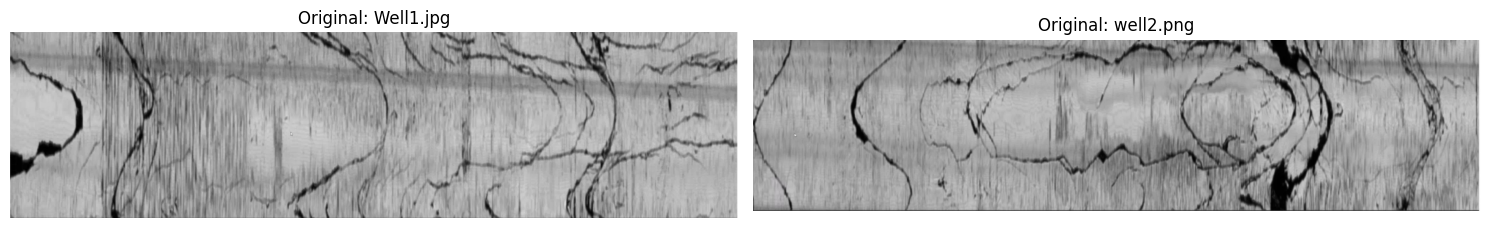

In [4]:
def load_image(file_path):
    """Load and prepare image for processing"""
    img = mpimg.imread(file_path)

    # Display image info
    print(f"Loaded: {file_path}")
    print(f"  Shape: {img.shape}")
    print(f"  Dtype: {img.dtype}")
    print(f"  Range: [{np.min(img):.3f}, {np.max(img):.3f}]")

    return img

# Load images
image_paths = ['Well1.jpg', 'well2.png']
original_images = []

fig, axes = plt.subplots(1, len(image_paths), figsize=(15, 5))

for idx, path in enumerate(image_paths):
    try:
        img = load_image(path)
        original_images.append(img)

        if len(image_paths) > 1:
            axes[idx].imshow(img, cmap='gray')
            axes[idx].set_title(f'Original: {path}')
            axes[idx].axis('off')
        else:
            axes.imshow(img, cmap='gray')
            axes.set_title(f'Original: {path}')
            axes.axis('off')
    except Exception as e:
        print(f"Error loading {path}: {e}")

plt.tight_layout()
plt.show()

## Step 1 - Convert to Grayscale and Normalize


Processing image 1:
  Converted RGB to grayscale
  Final range: [0.000, 1.000]

Processing image 2:
  Converted RGBA to grayscale
  Final range: [0.000, 1.000]


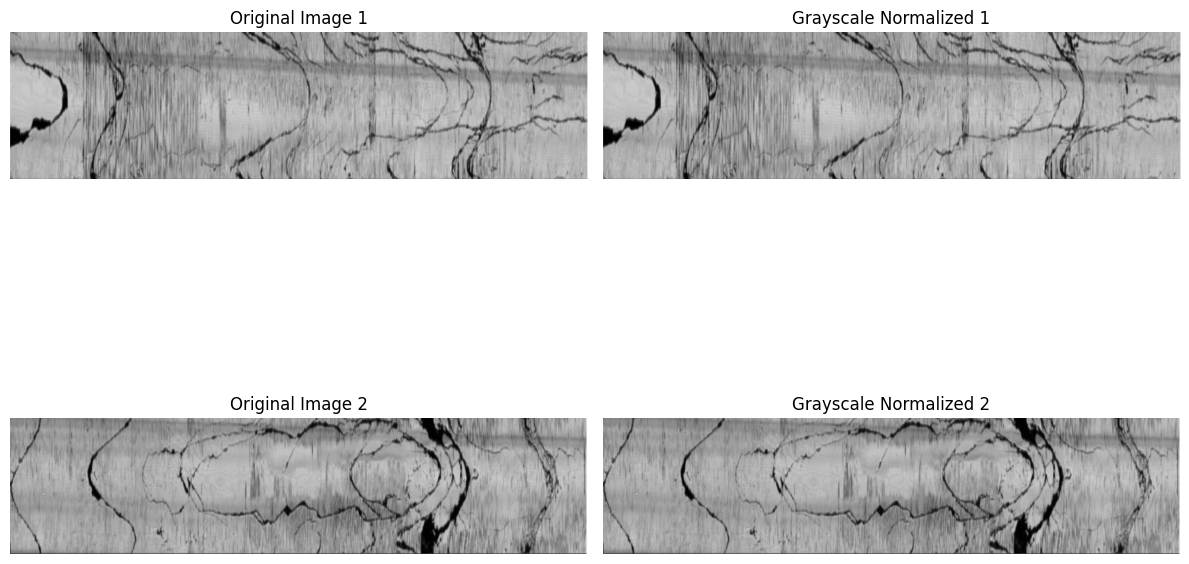

In [5]:
def convert_to_grayscale(img):
    """
    Convert image to grayscale and normalize to [0, 1] range

    Handles different image formats:
    - Grayscale images
    - RGB images
    - RGBA images (ignores alpha channel)
    """
    # Handle different image shapes
    if len(img.shape) == 2:
        gray = img
        print("  Already grayscale")
    elif len(img.shape) == 3:
        if img.shape[2] == 4:
            gray = np.mean(img[:, :, :3], axis=2)  # Mean of RGB, ignore alpha
            print("  Converted RGBA to grayscale")
        elif img.shape[2] == 3:
            gray = np.mean(img, axis=2)
            print("  Converted RGB to grayscale")
        else:
            raise ValueError("Unsupported number of channels")
    else:
        raise ValueError("Unsupported image shape")

    # Normalize to [0,1] if not already
    if gray.dtype == np.uint8:
        gray = gray / 255.0
        print("  Normalized from uint8 to [0,1]")

    # Ensure full [0,1] range
    gray = (gray - np.min(gray)) / (np.max(gray) - np.min(gray) + 1e-8)
    print(f"  Final range: [{np.min(gray):.3f}, {np.max(gray):.3f}]")

    return gray

grayscale_images = []
fig, axes = plt.subplots(len(original_images), 2, figsize=(12, 5*len(original_images)))

for idx, img in enumerate(original_images):
    print(f"\nProcessing image {idx + 1}:")
    gray = convert_to_grayscale(img)
    grayscale_images.append(gray)

    if len(original_images) > 1:
        axes[idx, 0].imshow(img if len(img.shape) == 2 else img, cmap='gray')
        axes[idx, 0].set_title(f'Original Image {idx+1}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(gray, cmap='gray')
        axes[idx, 1].set_title(f'Grayscale Normalized {idx+1}')
        axes[idx, 1].axis('off')
    else:
        axes[0].imshow(img if len(img.shape) == 2 else img, cmap='gray')
        axes[0].set_title('Original Image')
        axes[0].axis('off')

        axes[1].imshow(gray, cmap='gray')
        axes[1].set_title('Grayscale Normalized')
        axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 2 - Denoising with Gaussian Filter


Denoising image 1:
  Applied Gaussian filter with sigma=1.0
  Noise reduction: 0.002207

Denoising image 2:
  Applied Gaussian filter with sigma=1.0
  Noise reduction: 0.002165


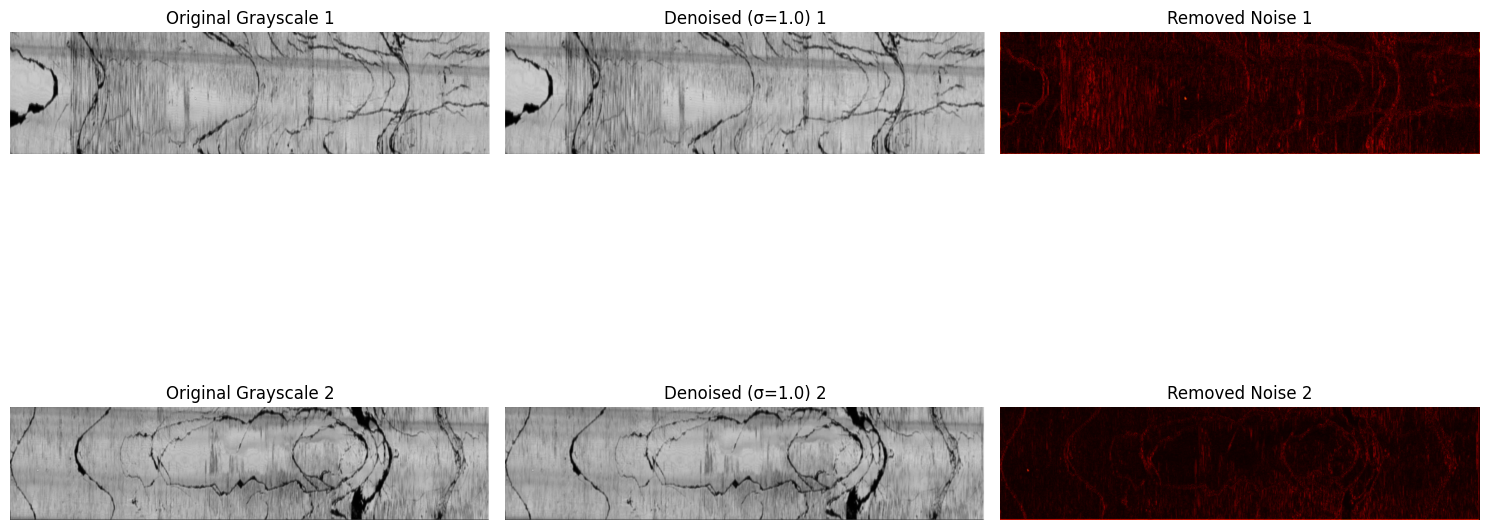

In [6]:
def denoise_image(gray, sigma=1.0):
    """
    Apply Gaussian filter to reduce noise while preserving crack edges

    Parameters:
    -----------
    gray : numpy array
        Grayscale image
    sigma : float
        Standard deviation for Gaussian kernel (higher = more smoothing)

    Returns:
    --------
    denoised : numpy array
        Smoothed image
    """
    denoised = gaussian_filter(gray, sigma=sigma)
    print(f"  Applied Gaussian filter with sigma={sigma}")
    print(f"  Noise reduction: {np.std(gray) - np.std(denoised):.6f}")
    return denoised

denoised_images = []
fig, axes = plt.subplots(len(grayscale_images), 3, figsize=(15, 5*len(grayscale_images)))

for idx, gray in enumerate(grayscale_images):
    print(f"\nDenoising image {idx + 1}:")
    denoised = denoise_image(gray, sigma=1.0)
    denoised_images.append(denoised)

    # Calculate difference to visualize noise removed
    noise = np.abs(gray - denoised)

    if len(grayscale_images) > 1:
        axes[idx, 0].imshow(gray, cmap='gray')
        axes[idx, 0].set_title(f'Original Grayscale {idx+1}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(denoised, cmap='gray')
        axes[idx, 1].set_title(f'Denoised (σ=1.0) {idx+1}')
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(noise, cmap='hot')
        axes[idx, 2].set_title(f'Removed Noise {idx+1}')
        axes[idx, 2].axis('off')
    else:
        axes[0].imshow(gray, cmap='gray')
        axes[0].set_title('Original Grayscale')
        axes[0].axis('off')

        axes[1].imshow(denoised, cmap='gray')
        axes[1].set_title('Denoised (σ=1.0)')
        axes[1].axis('off')

        axes[2].imshow(noise, cmap='hot')
        axes[2].set_title('Removed Noise')
        axes[2].axis('off')

plt.tight_layout()
plt.show()

## Step 3 - Adaptive Thresholding


Adaptive thresholding image 1:
  Local mean computed with sigma=20.0
  Threshold offset=0.05
  Detected 16.61% of pixels as cracks

Adaptive thresholding image 2:
  Local mean computed with sigma=20.0
  Threshold offset=0.05
  Detected 15.82% of pixels as cracks


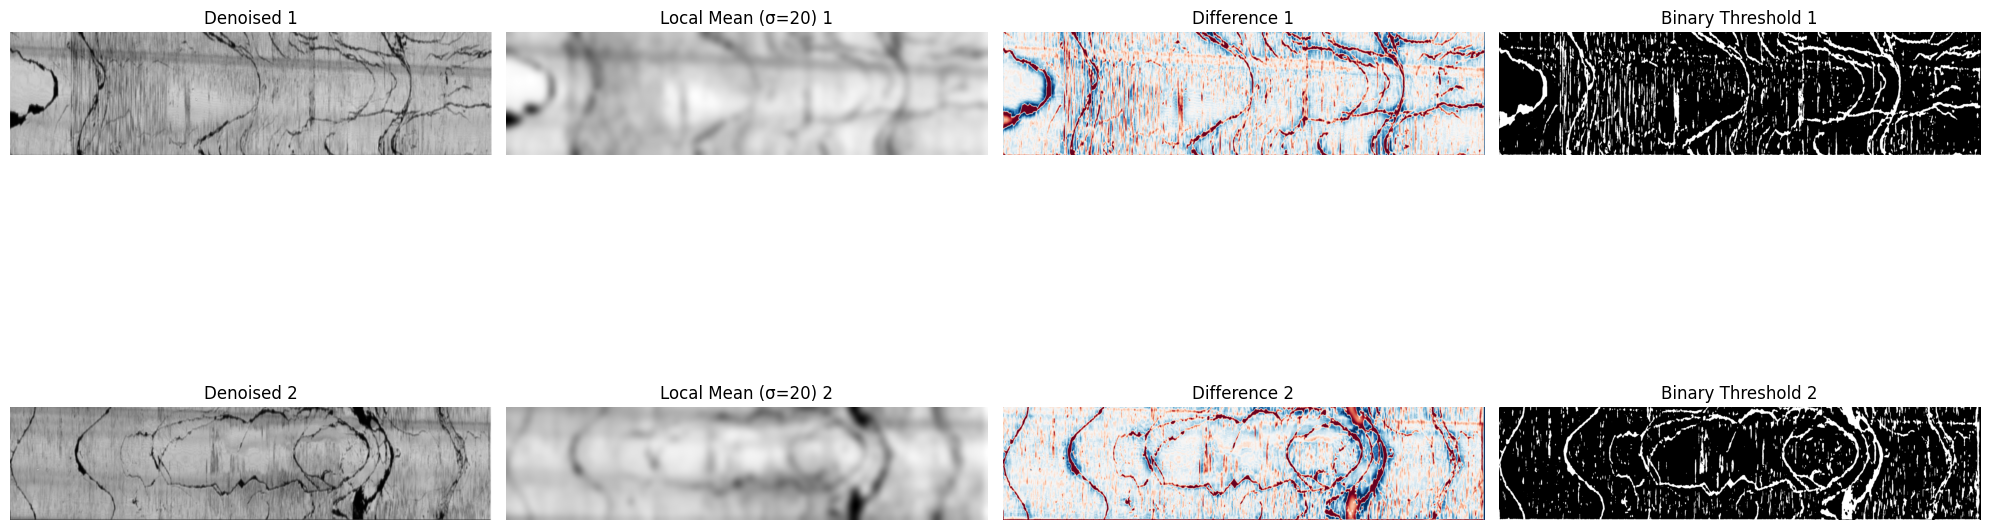

In [7]:
def adaptive_threshold(denoised, sigma=20.0, offset=0.05):
    """
    Apply adaptive thresholding to detect dark cracks

    Instead of a global threshold, this compares each pixel to its local
    neighborhood average. Cracks appear darker than surroundings.

    Parameters:
    -----------
    denoised : numpy array
        Denoised grayscale image
    sigma : float
        Size of local neighborhood (higher = larger area)
    offset : float
        How much darker a pixel must be to be considered a crack

    Returns:
    --------
    binary : numpy array (boolean)
        Binary mask where True = crack
    """
    # Calculate local mean with large Gaussian kernel
    local_mean = gaussian_filter(denoised, sigma=sigma)

    # Pixels significantly darker than local mean are cracks
    binary = denoised < (local_mean - offset)

    crack_percentage = 100 * np.sum(binary) / binary.size
    print(f"  Local mean computed with sigma={sigma}")
    print(f"  Threshold offset={offset}")
    print(f"  Detected {crack_percentage:.2f}% of pixels as cracks")

    return binary, local_mean

binary_images = []
fig, axes = plt.subplots(len(denoised_images), 4, figsize=(20, 5*len(denoised_images)))

for idx, denoised in enumerate(denoised_images):
    print(f"\nAdaptive thresholding image {idx + 1}:")
    binary, local_mean = adaptive_threshold(denoised, sigma=20.0, offset=0.05)
    binary_images.append(binary)

    if len(denoised_images) > 1:
        axes[idx, 0].imshow(denoised, cmap='gray')
        axes[idx, 0].set_title(f'Denoised {idx+1}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(local_mean, cmap='gray')
        axes[idx, 1].set_title(f'Local Mean (σ=20) {idx+1}')
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(denoised - local_mean, cmap='RdBu', vmin=-0.2, vmax=0.2)
        axes[idx, 2].set_title(f'Difference {idx+1}')
        axes[idx, 2].axis('off')

        axes[idx, 3].imshow(binary, cmap='gray')
        axes[idx, 3].set_title(f'Binary Threshold {idx+1}')
        axes[idx, 3].axis('off')
    else:
        axes[0].imshow(denoised, cmap='gray')
        axes[0].set_title('Denoised')
        axes[0].axis('off')

        axes[1].imshow(local_mean, cmap='gray')
        axes[1].set_title('Local Mean (σ=20)')
        axes[1].axis('off')

        axes[2].imshow(denoised - local_mean, cmap='RdBu', vmin=-0.2, vmax=0.2)
        axes[2].set_title('Difference')
        axes[2].axis('off')

        axes[3].imshow(binary, cmap='gray')
        axes[3].set_title('Binary Threshold')
        axes[3].axis('off')

plt.tight_layout()
plt.show()

## Step 4 - Morphological Closing


Morphological closing image 1:
  Applied closing with 3x3 structure
  Added -557 pixels (-0.033%)

Morphological closing image 2:
  Applied closing with 3x3 structure
  Added -1524 pixels (-0.099%)


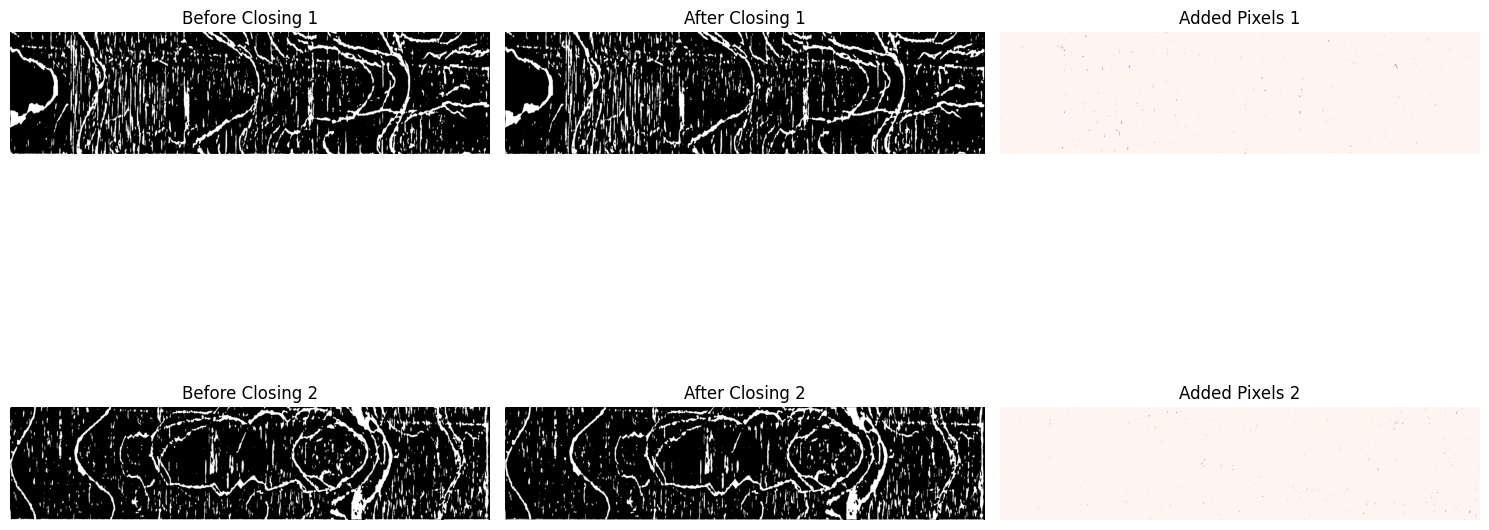

In [8]:
def morphological_close(binary, structure_size=3):
    """
    Apply morphological closing to connect nearby crack segments

    Closing = Dilation followed by Erosion
    This fills small gaps in cracks and connects nearby segments

    Parameters:
    -----------
    binary : numpy array (boolean)
        Binary crack mask
    structure_size : int
        Size of structuring element (higher = more aggressive closing)

    Returns:
    --------
    closed : numpy array (boolean)
        Closed binary image
    """
    structure = np.ones((structure_size, structure_size))
    closed = binary_closing(binary, structure=structure)

    added_pixels = np.sum(closed) - np.sum(binary)
    print(f"  Applied closing with {structure_size}x{structure_size} structure")
    print(f"  Added {added_pixels} pixels ({100*added_pixels/binary.size:.3f}%)")

    return closed

closed_images = []
fig, axes = plt.subplots(len(binary_images), 3, figsize=(15, 5*len(binary_images)))

for idx, binary in enumerate(binary_images):
    print(f"\nMorphological closing image {idx + 1}:")
    closed = morphological_close(binary, structure_size=3)
    closed_images.append(closed)

    # Show what was added
    added = np.logical_and(closed, np.logical_not(binary))

    if len(binary_images) > 1:
        axes[idx, 0].imshow(binary, cmap='gray')
        axes[idx, 0].set_title(f'Before Closing {idx+1}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(closed, cmap='gray')
        axes[idx, 1].set_title(f'After Closing {idx+1}')
        axes[idx, 1].axis('off')

        axes[idx, 2].imshow(added, cmap='Reds')
        axes[idx, 2].set_title(f'Added Pixels {idx+1}')
        axes[idx, 2].axis('off')
    else:
        axes[0].imshow(binary, cmap='gray')
        axes[0].set_title('Before Closing')
        axes[0].axis('off')

        axes[1].imshow(closed, cmap='gray')
        axes[1].set_title('After Closing')
        axes[1].axis('off')

        axes[2].imshow(added, cmap='Reds')
        axes[2].set_title('Added Pixels')
        axes[2].axis('off')

plt.tight_layout()
plt.show()

## Step 5 - Label Connected Components


Labeling components in image 1:
  Found 949 connected components
  Component sizes: min=1, max=31242, mean=293

Labeling components in image 2:
  Found 877 connected components
  Component sizes: min=1, max=35376, mean=277


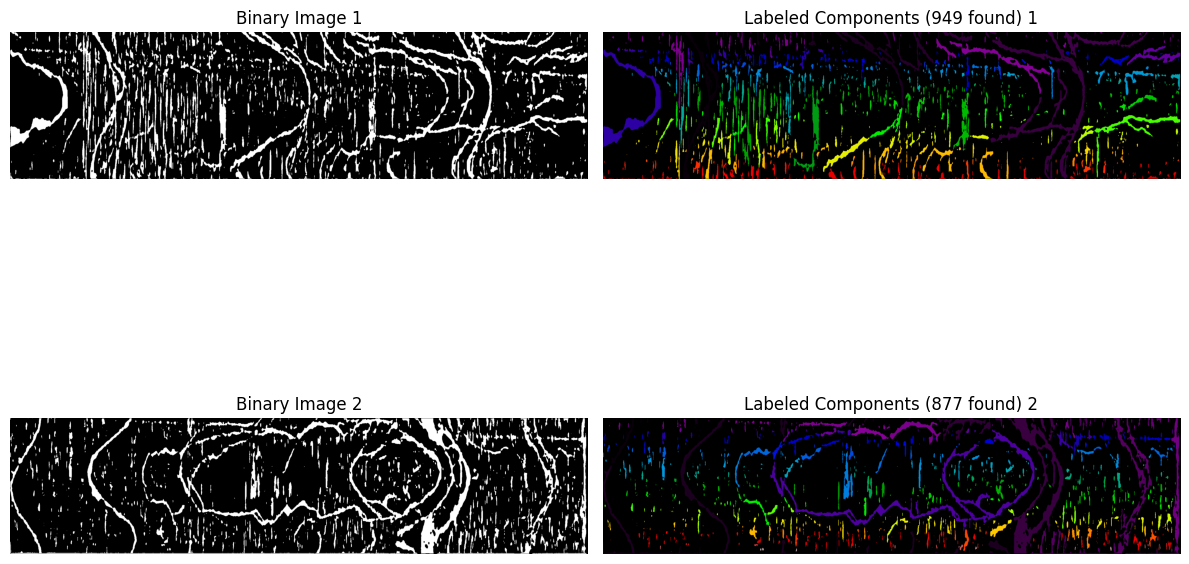

In [9]:
def label_components(closed):
    """
    Label each connected component (potential crack) with unique ID

    This separates different cracks so we can analyze them individually

    Parameters:
    -----------
    closed : numpy array (boolean)
        Binary image after closing

    Returns:
    --------
    labeled : numpy array (int)
        Labeled image where each component has unique integer ID
    num_labels : int
        Number of components found
    """
    labeled, num_labels = label(closed)
    print(f"  Found {num_labels} connected components")

    # Get component sizes
    component_sizes = []
    for i in range(1, num_labels + 1):
        size = np.sum(labeled == i)
        component_sizes.append(size)

    if num_labels > 0:
        print(f"  Component sizes: min={min(component_sizes)}, "
              f"max={max(component_sizes)}, mean={np.mean(component_sizes):.0f}")

    return labeled, num_labels

labeled_images = []
fig, axes = plt.subplots(len(closed_images), 2, figsize=(12, 5*len(closed_images)))

for idx, closed in enumerate(closed_images):
    print(f"\nLabeling components in image {idx + 1}:")
    labeled, num_labels = label_components(closed)
    labeled_images.append((labeled, num_labels))

    if len(closed_images) > 1:
        axes[idx, 0].imshow(closed, cmap='gray')
        axes[idx, 0].set_title(f'Binary Image {idx+1}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(labeled, cmap='nipy_spectral')
        axes[idx, 1].set_title(f'Labeled Components ({num_labels} found) {idx+1}')
        axes[idx, 1].axis('off')
    else:
        axes[0].imshow(closed, cmap='gray')
        axes[0].set_title('Binary Image')
        axes[0].axis('off')

        axes[1].imshow(labeled, cmap='nipy_spectral')
        axes[1].set_title(f'Labeled Components ({num_labels} found)')
        axes[1].axis('off')

plt.tight_layout()
plt.show()

## Step 6 - Filter Main Cracks by Criteria


Filtering main cracks in image 1:
  Filtering criteria:
    - Vertical span >= 90% (589 pixels)
    - Max half-thickness > 4.0 pixels

  ✓ Component 5: span=652px (99.7%), thickness≈27.8px, area=13438px²
  ✓ Component 24: span=652px (99.7%), thickness≈26.8px, area=31242px²

  Result: 2 main cracks detected

Filtering main cracks in image 2:
  Filtering criteria:
    - Vertical span >= 95% (573 pixels)
    - Max half-thickness > 4.0 pixels

  ✓ Component 11: span=601px (99.7%), thickness≈29.5px, area=24827px²
  ✓ Component 22: span=600px (99.5%), thickness≈50.0px, area=31793px²
  ✓ Component 33: span=601px (99.7%), thickness≈24.3px, area=16702px²
  ✓ Component 43: span=601px (99.7%), thickness≈24.7px, area=8784px²

  Result: 4 main cracks detected


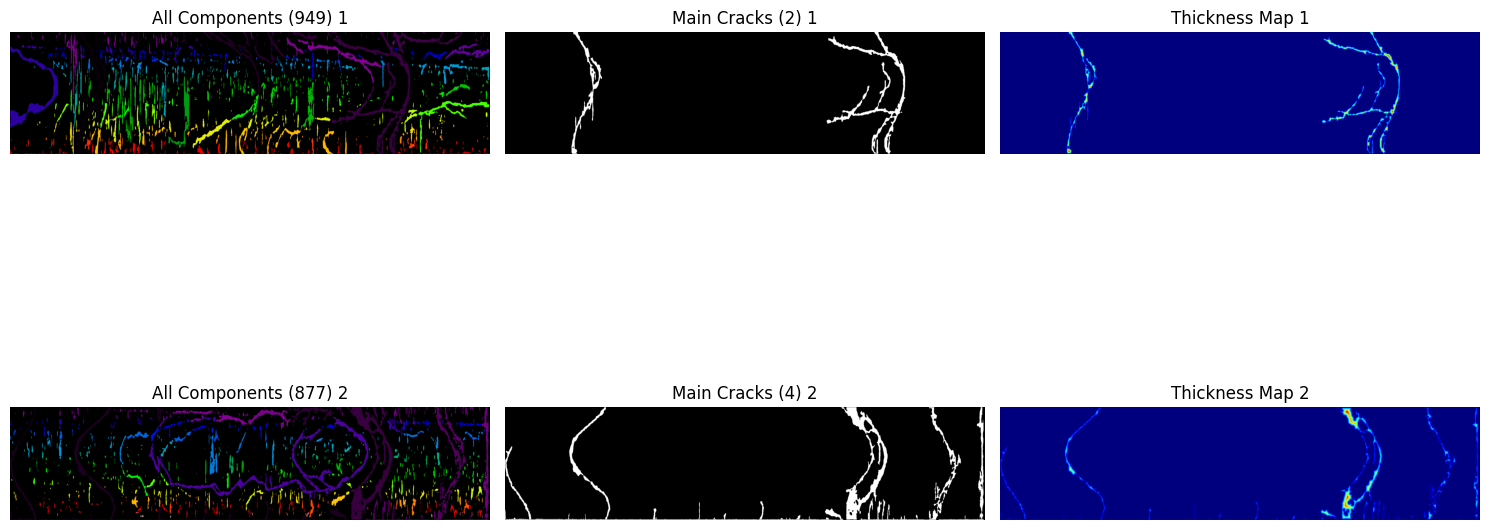

In [10]:
def filter_main_cracks(labeled, num_labels, img_height,
                      span_threshold=0.9, thickness_threshold=4.0):
    """
    Filter components to keep only main cracks based on:
    1. Vertical span - must extend through most of wellbore height
    2. Thickness - must have sufficient width (using distance transform)

    Parameters:
    -----------
    labeled : numpy array
        Labeled components
    num_labels : int
        Number of components
    img_height : int
        Image height in pixels
    span_threshold : float
        Minimum fraction of image height crack must span (0.9 = 90%)
    thickness_threshold : float
        Minimum half-thickness in pixels (using distance transform)

    Returns:
    --------
    main_crack_mask : numpy array (boolean)
        Binary mask of main cracks only
    filtered_info : list
        Information about each main crack detected
    """
    main_crack_mask = np.zeros_like(labeled, dtype=bool)
    filtered_info = []

    print(f"  Filtering criteria:")
    print(f"    - Vertical span >= {span_threshold*100:.0f}% ({span_threshold*img_height:.0f} pixels)")
    print(f"    - Max half-thickness > {thickness_threshold} pixels")
    print()

    for i in range(1, num_labels + 1):
        component = (labeled == i)

        # Criterion 1: Vertical span
        rows = np.any(component, axis=1)
        span = np.sum(rows)
        span_ratio = span / img_height

        if span < span_threshold * img_height:
            continue  # Reject: insufficient vertical span

        # Criterion 2: Thickness using distance transform
        # Distance transform gives distance to nearest background pixel
        # Max value = half-width of thickest part
        dist = distance_transform_edt(component)
        max_half_thick = np.max(dist)

        if max_half_thick <= thickness_threshold:
            continue  # Reject: too thin

        # Accept this crack
        main_crack_mask |= component
        filtered_info.append({
            'id': i,
            'span_pixels': span,
            'span_ratio': span_ratio,
            'max_half_thickness': max_half_thick,
            'thickness_estimate': max_half_thick * 2,
            'area': np.sum(component)
        })

        print(f"  ✓ Component {i}: span={span}px ({span_ratio:.1%}), "
              f"thickness≈{max_half_thick*2:.1f}px, area={np.sum(component)}px²")

    print(f"\n  Result: {len(filtered_info)} main cracks detected")
    return main_crack_mask, filtered_info

main_crack_results = []
fig, axes = plt.subplots(len(labeled_images), 3, figsize=(15, 5*len(labeled_images)))

for idx, (labeled, num_labels) in enumerate(labeled_images):
    print(f"\n{'='*60}")
    print(f"Filtering main cracks in image {idx + 1}:")
    print(f"{'='*60}")

    img_height = grayscale_images[idx].shape[0]
    main_crack_mask, info = filter_main_cracks(
        labeled, num_labels, img_height,
        span_threshold=0.95 if idx == 1 else 0.9,  # Stricter for well2.png
        thickness_threshold=4.0
    )
    main_crack_results.append((main_crack_mask, info))

    if len(labeled_images) > 1:
        axes[idx, 0].imshow(labeled, cmap='nipy_spectral')
        axes[idx, 0].set_title(f'All Components ({num_labels}) {idx+1}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(main_crack_mask, cmap='gray')
        axes[idx, 1].set_title(f'Main Cracks ({len(info)}) {idx+1}')
        axes[idx, 1].axis('off')

        # Show distance transform on main cracks
        dist_vis = distance_transform_edt(main_crack_mask)
        axes[idx, 2].imshow(dist_vis, cmap='jet')
        axes[idx, 2].set_title(f'Thickness Map {idx+1}')
        axes[idx, 2].axis('off')
    else:
        axes[0].imshow(labeled, cmap='nipy_spectral')
        axes[0].set_title(f'All Components ({num_labels})')
        axes[0].axis('off')

        axes[1].imshow(main_crack_mask, cmap='gray')
        axes[1].set_title(f'Main Cracks ({len(info)})')
        axes[1].axis('off')

        dist_vis = distance_transform_edt(main_crack_mask)
        axes[2].imshow(dist_vis, cmap='jet')
        axes[2].set_title('Thickness Map')
        axes[2].axis('off')

plt.tight_layout()
plt.show()

## Step 6.5 - Morphological Thinning (Optional)


Applying morphological thinning to create crack skeletons:

Thinning image 1:
Thinning converged after 17 iterations

Thinning image 2:
Thinning converged after 30 iterations


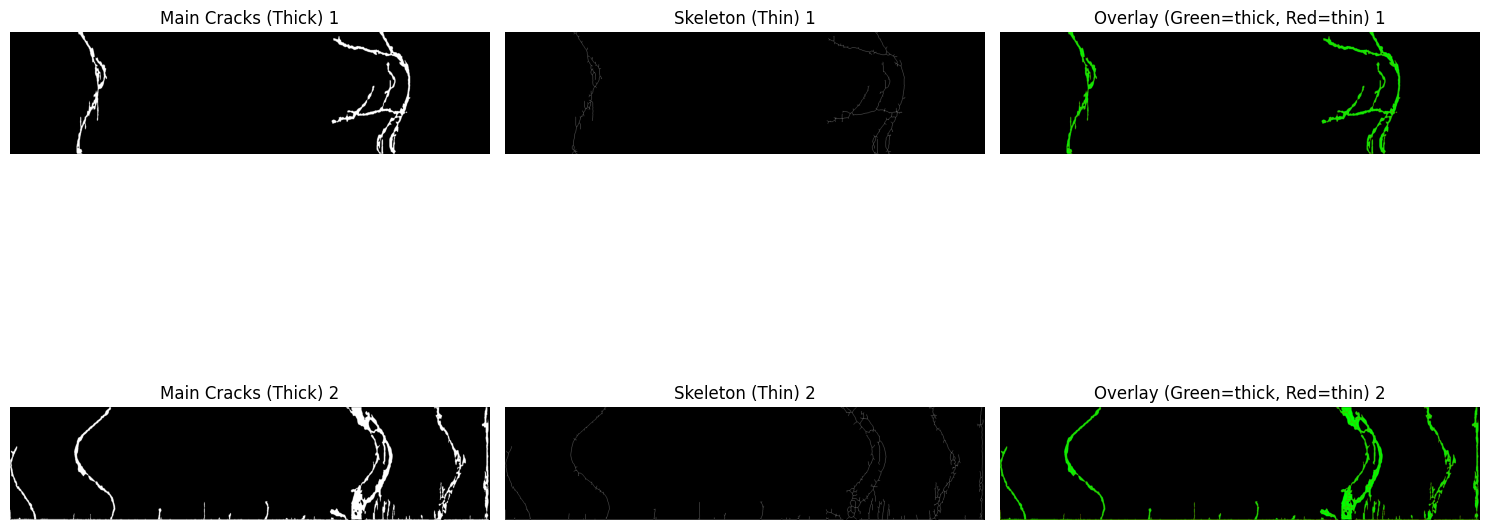

In [11]:
print("\n" + "="*60)
print("Applying morphological thinning to create crack skeletons:")
print("="*60)

skeleton_results = []
fig, axes = plt.subplots(len(main_crack_results), 3, figsize=(15, 5*len(main_crack_results)))

for idx, (main_crack_mask, info) in enumerate(main_crack_results):
    print(f"\nThinning image {idx + 1}:")
    skeleton = thin(main_crack_mask)
    skeleton_results.append(skeleton)

    if len(main_crack_results) > 1:
        axes[idx, 0].imshow(main_crack_mask, cmap='gray')
        axes[idx, 0].set_title(f'Main Cracks (Thick) {idx+1}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(skeleton, cmap='gray')
        axes[idx, 1].set_title(f'Skeleton (Thin) {idx+1}')
        axes[idx, 1].axis('off')

        # Overlay both
        overlay_vis = np.zeros((*main_crack_mask.shape, 3))
        overlay_vis[main_crack_mask] = [0, 1, 0]  # Green: thick
        overlay_vis[skeleton] = [1, 0, 0]  # Red: skeleton
        axes[idx, 2].imshow(overlay_vis)
        axes[idx, 2].set_title(f'Overlay (Green=thick, Red=thin) {idx+1}')
        axes[idx, 2].axis('off')
    else:
        axes[0].imshow(main_crack_mask, cmap='gray')
        axes[0].set_title('Main Cracks (Thick)')
        axes[0].axis('off')

        axes[1].imshow(skeleton, cmap='gray')
        axes[1].set_title('Skeleton (Thin)')
        axes[1].axis('off')

        overlay_vis = np.zeros((*main_crack_mask.shape, 3))
        overlay_vis[main_crack_mask] = [0, 1, 0]
        overlay_vis[skeleton] = [1, 0, 0]
        axes[2].imshow(overlay_vis)
        axes[2].set_title('Overlay (Green=thick, Red=thin)')
        axes[2].axis('off')

plt.tight_layout()
plt.show()

## Step 7 - Create Red Overlay on Original Images


Creating overlay for image 1:

Creating overlay for image 2:


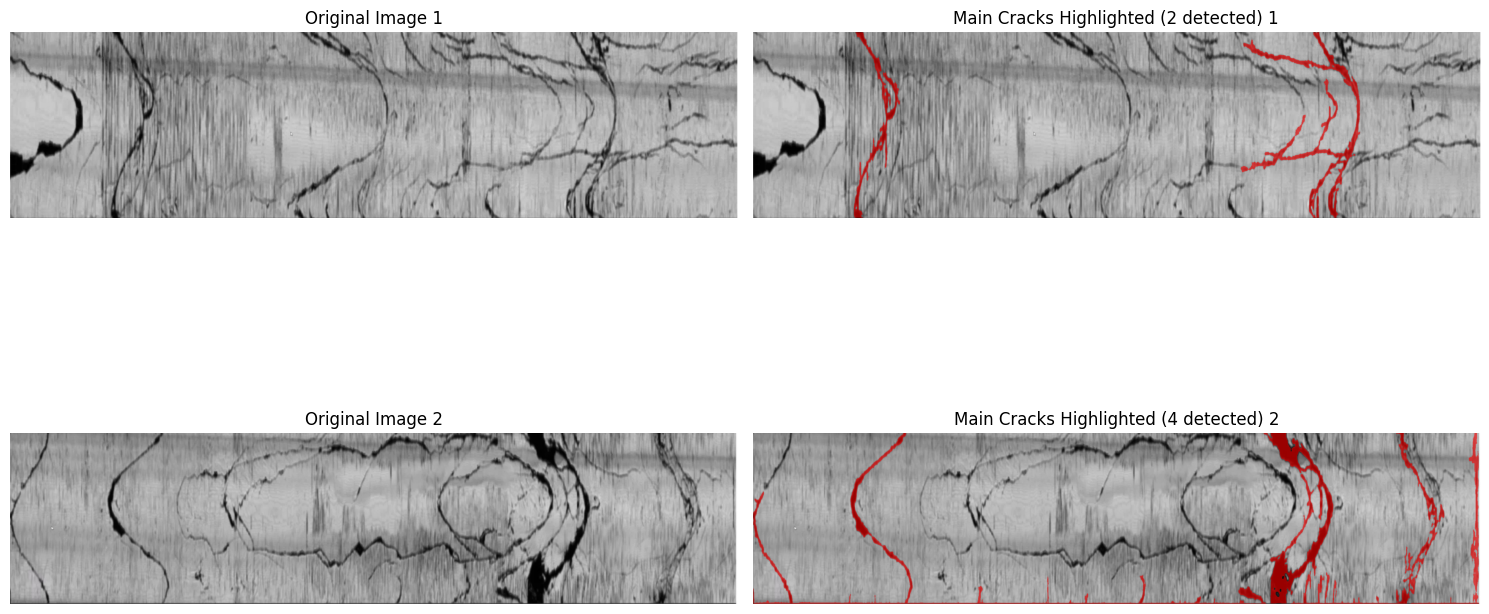

In [12]:
def create_overlay(original_img, main_crack_mask, alpha=0.5):
    """
    Create visualization with main cracks highlighted in red

    Parameters:
    -----------
    original_img : numpy array
        Original image (grayscale or RGB)
    main_crack_mask : numpy array (boolean)
        Binary mask of main cracks
    alpha : float
        Transparency of overlay (0=transparent, 1=opaque)

    Returns:
    --------
    overlay : numpy array
        RGB image with red highlighted cracks
    """
    # Convert to RGB if needed
    if len(original_img.shape) == 2:
        # Grayscale
        rgb_base = np.stack([original_img, original_img, original_img], axis=-1)
    elif len(original_img.shape) == 3:
        if original_img.shape[2] == 4:
            # RGBA - take RGB only
            rgb_base = original_img[:, :, :3].copy()
        elif original_img.shape[2] == 3:
            # Already RGB
            rgb_base = original_img.copy()
        else:
            raise ValueError("Unsupported image format")
    else:
        raise ValueError("Unsupported image shape")

    # Create overlay
    overlay = rgb_base.copy()
    red_color = [1.0, 0, 0] if overlay.dtype == np.float64 or overlay.max() <= 1.0 else [255, 0, 0]

    # Blend red with original
    for i in range(3):
        overlay[main_crack_mask, i] = (1 - alpha) * rgb_base[main_crack_mask, i] + alpha * red_color[i]

    return overlay

final_overlays = []
fig, axes = plt.subplots(len(original_images), 2, figsize=(15, 5*len(original_images)))

for idx, (orig_img, (main_crack_mask, info)) in enumerate(zip(original_images, main_crack_results)):
    print(f"\nCreating overlay for image {idx + 1}:")
    overlay = create_overlay(orig_img, main_crack_mask, alpha=0.6)
    final_overlays.append(overlay)

    if len(original_images) > 1:
        # Original
        axes[idx, 0].imshow(orig_img if len(orig_img.shape) == 3 else orig_img, cmap='gray')
        axes[idx, 0].set_title(f'Original Image {idx+1}')
        axes[idx, 0].axis('off')

        # With overlay
        axes[idx, 1].imshow(overlay)
        axes[idx, 1].set_title(f'Main Cracks Highlighted ({len(info)} detected) {idx+1}')
        axes[idx, 1].axis('off')
    else:
        axes[0].imshow(orig_img if len(orig_img.shape) == 3 else orig_img, cmap='gray')
        axes[0].set_title('Original Image')
        axes[0].axis('off')

        axes[1].imshow(overlay)
        axes[1].set_title(f'Main Cracks Highlighted ({len(info)} detected)')
        axes[1].axis('off')

plt.tight_layout()
plt.show()

## Complete Pipeline Function

In [13]:
def detect_wellbore_cracks_complete(file_path,
                                   span_threshold=0.9,
                                   thickness_threshold=4.0,
                                   offset_threshold=0.05,
                                   visualize=True):
    """
    Complete pipeline to detect main cracks in wellbore images

    Parameters:
    -----------
    file_path : str
        Path to the wellbore image
    span_threshold : float
        Minimum vertical span ratio (0.9 = 90% of image height)
    thickness_threshold : float
        Minimum half-thickness in pixels
    offset_threshold : float
        Adaptive threshold offset
    visualize : bool
        Whether to display results

    Returns:
    --------
    gray : grayscale image
    binary : binary thresholded image
    main_crack_mask : filtered main cracks
    overlay : original with red highlights
    crack_info : list of detected crack information
    """
    # Load image
    img = mpimg.imread(file_path)

    # Step 1: Convert to grayscale and normalize
    if len(img.shape) == 2:
        gray = img
    elif len(img.shape) == 3:
        if img.shape[2] == 4:
            gray = np.mean(img[:, :, :3], axis=2)
        elif img.shape[2] == 3:
            gray = np.mean(img, axis=2)

    if gray.dtype == np.uint8:
        gray = gray / 255.0
    gray = (gray - np.min(gray)) / (np.max(gray) - np.min(gray) + 1e-8)

    # Step 2: Denoising
    denoised = gaussian_filter(gray, sigma=1.0)

    # Step 3: Adaptive thresholding
    local_mean = gaussian_filter(denoised, sigma=20.0)
    binary = denoised < (local_mean - offset_threshold)

    # Step 4: Morphological closing
    closed = binary_closing(binary, structure=np.ones((3, 3)))

    # Step 5: Label connected components
    labeled, num_labels = label(closed)

    # Step 6: Filter main cracks
    img_height = gray.shape[0]
    main_crack_mask = np.zeros_like(binary)
    crack_info = []

    for i in range(1, num_labels + 1):
        component = (labeled == i)

        # Vertical span
        rows = np.any(component, axis=1)
        span = np.sum(rows)
        if span < span_threshold * img_height:
            continue

        # Thickness using distance transform
        dist = distance_transform_edt(component)
        max_half_thick = np.max(dist)
        if max_half_thick > thickness_threshold:
            main_crack_mask |= component
            crack_info.append({
                'span': span,
                'span_ratio': span / img_height,
                'thickness': max_half_thick * 2,
                'area': np.sum(component)
            })

    # Step 7: Create overlay
    overlay = create_overlay(img, main_crack_mask)

    if visualize:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        axes[0, 0].imshow(gray, cmap='gray')
        axes[0, 0].set_title('Grayscale Normalized')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(binary, cmap='gray')
        axes[0, 1].set_title('Adaptive Threshold')
        axes[0, 1].axis('off')

        axes[1, 0].imshow(main_crack_mask, cmap='gray')
        axes[1, 0].set_title(f'Main Cracks ({len(crack_info)} detected)')
        axes[1, 0].axis('off')

        axes[1, 1].imshow(overlay)
        axes[1, 1].set_title('Final Result - Red Overlay')
        axes[1, 1].axis('off')

        plt.tight_layout()
        plt.show()

        print(f"\n{'='*60}")
        print(f"Results for: {file_path}")
        print(f"{'='*60}")
        print(f"Detected {len(crack_info)} main cracks:")
        for i, crack in enumerate(crack_info, 1):
            print(f"  Crack {i}: span={crack['span']}px ({crack['span_ratio']:.1%}), "
                  f"thickness≈{crack['thickness']:.1f}px, area={crack['area']}px²")

    return gray, binary, main_crack_mask, overlay, crack_info

print("Complete pipeline function defined!")

Complete pipeline function defined!


## Run Complete Pipeline on All Images


RUNNING COMPLETE PIPELINE ON ALL IMAGES

Processing: Well1.jpg


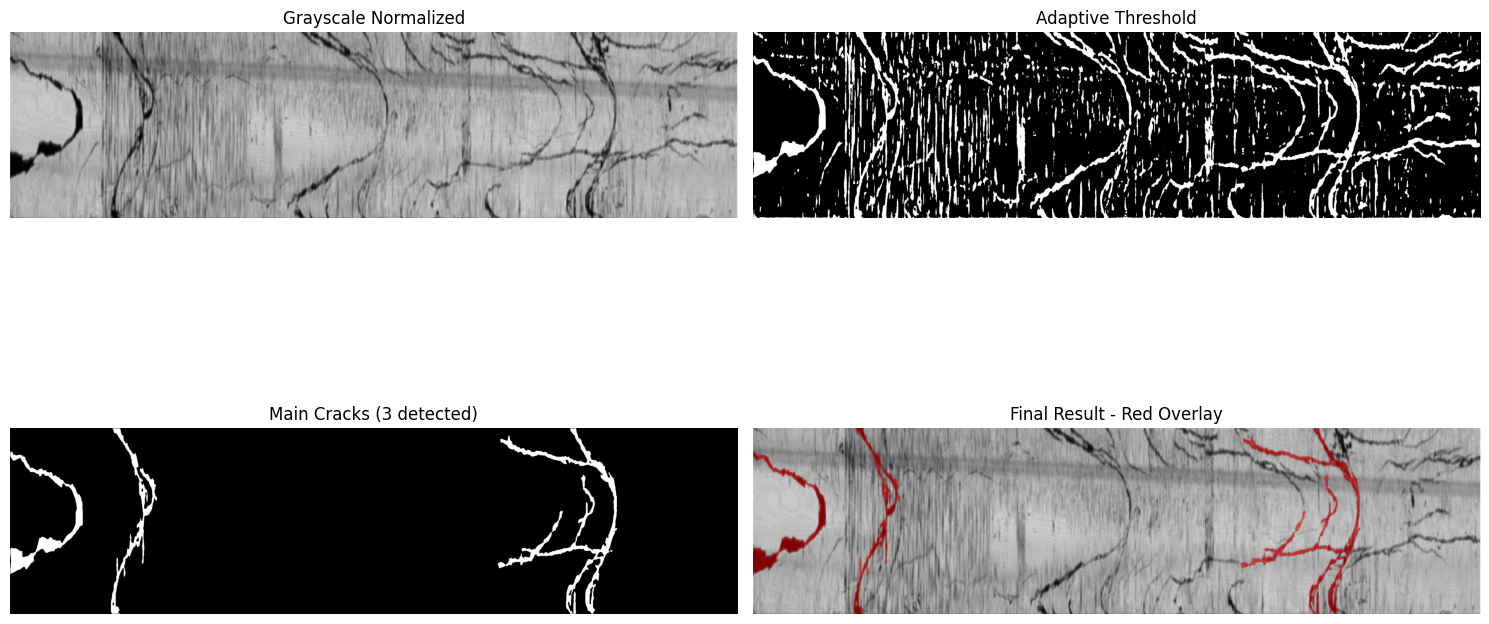


Results for: Well1.jpg
Detected 3 main cracks:
  Crack 1: span=652px (99.7%), thickness≈27.8px, area=13438px²
  Crack 2: span=652px (99.7%), thickness≈26.8px, area=31242px²
  Crack 3: span=432px (66.1%), thickness≈49.5px, area=16249px²

Processing: well2.png


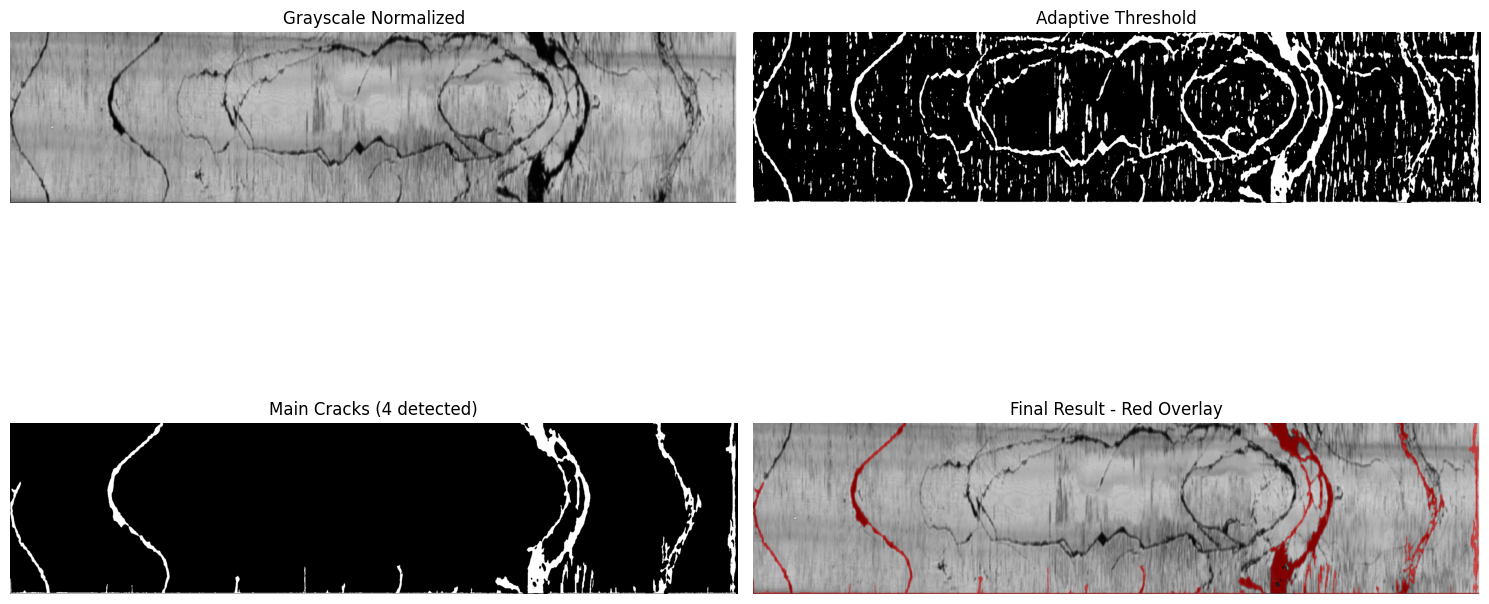


Results for: well2.png
Detected 4 main cracks:
  Crack 1: span=601px (99.7%), thickness≈29.5px, area=24827px²
  Crack 2: span=600px (99.5%), thickness≈50.0px, area=31793px²
  Crack 3: span=601px (99.7%), thickness≈24.3px, area=16702px²
  Crack 4: span=601px (99.7%), thickness≈24.7px, area=8784px²


In [15]:
print("\n" + "="*70)
print("RUNNING COMPLETE PIPELINE ON ALL IMAGES")
print("="*70)

results_all = []

for idx, path in enumerate(image_paths):
    try:
        print(f"\n{'='*70}")
        print(f"Processing: {path}")
        print(f"{'='*70}")

        # Use stricter parameters for well2.png
        if 'well2' in path.lower():
            gray, binary, mask, overlay, info = detect_wellbore_cracks_complete(
                path,
                span_threshold=0.95,
                thickness_threshold=8.0,
                offset_threshold=0.05,
                visualize=True
            )
        else:
            gray, binary, mask, overlay, info = detect_wellbore_cracks_complete(
                path,
                span_threshold=0.6,
                thickness_threshold=8.0,
                offset_threshold=0.05,
                visualize=True
            )

        results_all.append({
            'path': path,
            'gray': gray,
            'binary': binary,
            'mask': mask,
            'overlay': overlay,
            'info': info
        })

    except Exception as e:
        print(f"Error processing {path}: {e}")
        import traceback
        traceback.print_exc()

## Summary and Comparison


FINAL SUMMARY

Well1.jpg:
  - 3 main cracks detected
    Crack 1: 99.7% vertical span, ≈27.8px thick
    Crack 2: 99.7% vertical span, ≈26.8px thick
    Crack 3: 66.1% vertical span, ≈49.5px thick

well2.png:
  - 4 main cracks detected
    Crack 1: 99.7% vertical span, ≈29.5px thick
    Crack 2: 99.5% vertical span, ≈50.0px thick
    Crack 3: 99.7% vertical span, ≈24.3px thick
    Crack 4: 99.7% vertical span, ≈24.7px thick


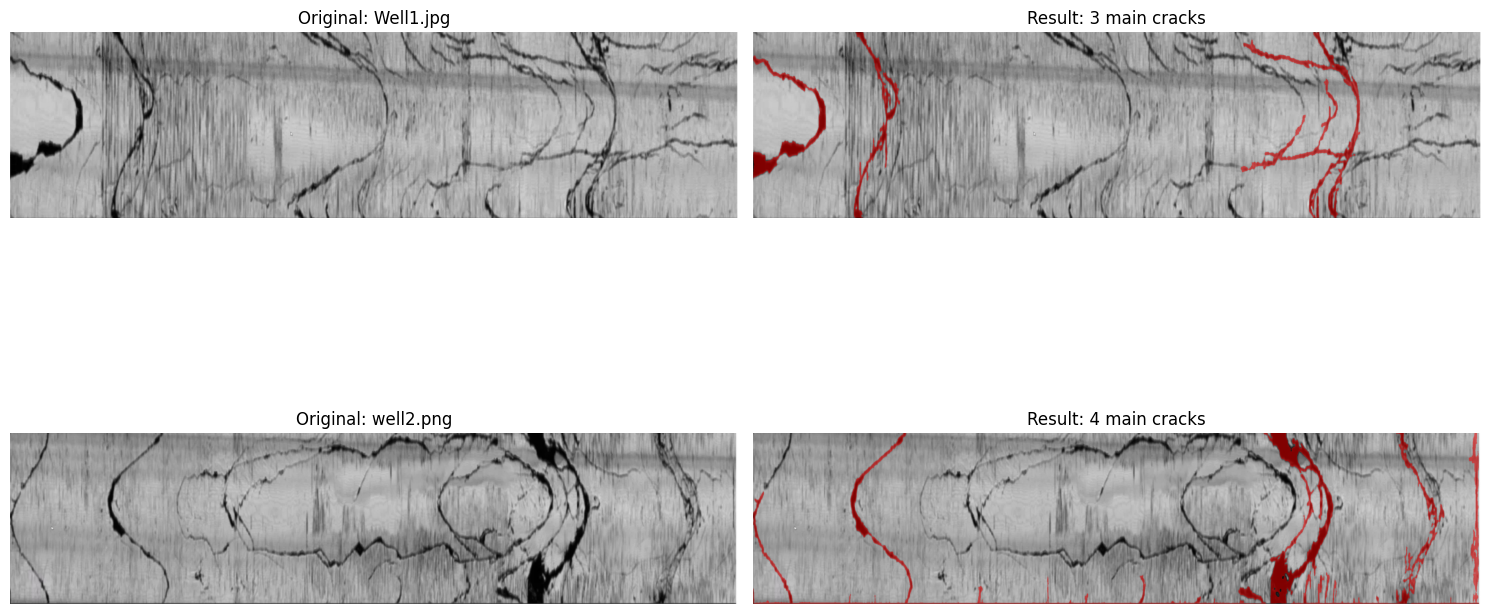


PROCESSING COMPLETE!


In [16]:
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)

fig, axes = plt.subplots(len(results_all), 2, figsize=(15, 5*len(results_all)))

for idx, result in enumerate(results_all):
    print(f"\n{result['path']}:")
    print(f"  - {len(result['info'])} main cracks detected")
    for i, crack in enumerate(result['info'], 1):
        print(f"    Crack {i}: {crack['span_ratio']:.1%} vertical span, "
              f"≈{crack['thickness']:.1f}px thick")

    if len(results_all) > 1:
        # Load original
        orig = mpimg.imread(result['path'])
        axes[idx, 0].imshow(orig if len(orig.shape) == 3 else orig, cmap='gray')
        axes[idx, 0].set_title(f"Original: {result['path']}")
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(result['overlay'])
        axes[idx, 1].set_title(f"Result: {len(result['info'])} main cracks")
        axes[idx, 1].axis('off')
    else:
        orig = mpimg.imread(result['path'])
        axes[0].imshow(orig if len(orig.shape) == 3 else orig, cmap='gray')
        axes[0].set_title(f"Original: {result['path']}")
        axes[0].axis('off')

        axes[1].imshow(result['overlay'])
        axes[1].set_title(f"Result: {len(result['info'])} main cracks")
        axes[1].axis('off')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("PROCESSING COMPLETE!")
print("="*70)

## Save Results (Optional)

In [17]:
def save_results(result, output_suffix='_result'):
    """Save processed images"""
    import os

    base_name = os.path.splitext(result['path'])[0]
    ext = os.path.splitext(result['path'])[1]

    # Save overlay
    overlay_path = f"{base_name}{output_suffix}{ext}"
    plt.imsave(overlay_path, result['overlay'])
    print(f"Saved overlay to: {overlay_path}")

    # Save mask
    mask_path = f"{base_name}_mask{ext}"
    plt.imsave(mask_path, result['mask'], cmap='gray')
    print(f"Saved mask to: {mask_path}")

# Uncomment to save:
for result in results_all:
    save_results(result)

Saved overlay to: Well1_result.jpg
Saved mask to: Well1_mask.jpg
Saved overlay to: well2_result.png
Saved mask to: well2_mask.png


# This section was done with the help of the Claude LLM

Oil Well Crack Detection and Separation Algorithm
==================================================

This notebook implements an advanced algorithm to automatically detect and separate
main cracks from thin cracks in oil well bore images using innovative signal processing
and image analysis techniques.

## 1. Import Required Libraries

In [18]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.signal import medfilt2d
from skimage import morphology, filters, measure
from skimage.morphology import skeletonize, remove_small_objects, disk, dilation
from skimage.filters import frangi, meijering, sato
import warnings
warnings.filterwarnings('ignore')

## 2. Load and Preprocess Images

In [19]:
def load_and_preprocess(image_path):
    """
    Load and preprocess the wellbore image.

    Parameters:
    -----------
    image_path : str
        Path to the input image

    Returns:
    --------
    img_gray : ndarray
        Grayscale preprocessed image
    """
    # Load image
    img = cv2.imread(image_path)

    # Convert to grayscale if needed
    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img.copy()

    # Normalize to 0-1 range
    img_gray = img_gray.astype(np.float64) / 255.0

    return img_gray


## 3. Multi-Scale Crack Enhancement

We use ridge detection filters (Frangi, Meijering) to enhance crack-like structures
at multiple scales. This helps distinguish cracks of different widths.

In [20]:
def enhance_cracks_multiscale(img, sigmas=range(1, 8, 1)):
    """
    Enhance crack structures using multi-scale ridge detection.

    Parameters:
    -----------
    img : ndarray
        Input grayscale image
    sigmas : range or list
        Scales for ridge detection (affects detected crack width)

    Returns:
    --------
    enhanced : ndarray
        Enhanced crack image
    """
    # Apply Frangi filter for ridge/vessel enhancement
    frangi_response = frangi(img, sigmas=sigmas, black_ridges=True)

    # Apply Meijering filter as complementary detection
    meijering_response = meijering(img, sigmas=sigmas, black_ridges=True)

    # Combine responses
    enhanced = np.maximum(frangi_response, meijering_response)

    # Normalize
    enhanced = (enhanced - enhanced.min()) / (enhanced.max() - enhanced.min() + 1e-8)

    return enhanced

## 4. Crack Segmentation and Skeletonization

In [21]:
def segment_cracks(enhanced_img, threshold_method='otsu'):
    """
    Segment cracks from enhanced image using adaptive thresholding.

    Parameters:
    -----------
    enhanced_img : ndarray
        Enhanced crack image
    threshold_method : str
        Thresholding method ('otsu', 'adaptive', or 'percentile')

    Returns:
    --------
    binary : ndarray
        Binary segmented crack mask
    """
    if threshold_method == 'otsu':
        # Otsu's thresholding
        threshold = filters.threshold_otsu(enhanced_img)
        binary = enhanced_img > threshold
    elif threshold_method == 'adaptive':
        # Adaptive thresholding
        threshold = filters.threshold_local(enhanced_img, block_size=51)
        binary = enhanced_img > threshold
    else:
        # Percentile-based threshold
        threshold = np.percentile(enhanced_img, 70)
        binary = enhanced_img > threshold

    return binary.astype(np.uint8)

def skeletonize_cracks(binary_mask):
    """
    Extract the skeleton of crack structures.

    Parameters:
    -----------
    binary_mask : ndarray
        Binary crack mask

    Returns:
    --------
    skeleton : ndarray
        Skeletonized crack structure
    """
    # Remove small noise
    cleaned = remove_small_objects(binary_mask.astype(bool), min_size=50)

    # Skeletonize
    skeleton = skeletonize(cleaned)

    return skeleton.astype(np.uint8)


## 5. Feature Extraction for Main Crack Identification

We analyze geometric and topological features to distinguish main cracks:
- **Continuity**: Main cracks span the entire wellbore width
- **Width/Diameter**: Main cracks have larger average width
- **Length**: Main cracks are longer
- **Straightness**: Main cracks tend to be more continuous

In [22]:
def extract_crack_features(binary_mask, skeleton):
    """
    Extract features for each connected crack component.

    Parameters:
    -----------
    binary_mask : ndarray
        Binary crack mask
    skeleton : ndarray
        Skeletonized crack structure

    Returns:
    --------
    features : list of dict
        Feature dictionary for each crack component
    labeled : ndarray
        Labeled image with each crack having unique ID
    """
    # Label connected components in skeleton
    labeled_skeleton = measure.label(skeleton, connectivity=2)

    # Also label in binary mask for width measurement
    labeled_binary = measure.label(binary_mask, connectivity=2)

    features = []

    for region in measure.regionprops(labeled_skeleton):
        if region.area < 20:  # Skip very small components
            continue

        # Extract coordinates
        coords = region.coords

        # Calculate features
        feature_dict = {
            'label': region.label,
            'area': region.area,  # Length of crack skeleton
            'bbox': region.bbox,
            'centroid': region.centroid,
            'coords': coords
        }

        # Calculate span (horizontal extent)
        min_col = coords[:, 1].min()
        max_col = coords[:, 1].max()
        feature_dict['horizontal_span'] = max_col - min_col

        # Calculate vertical extent
        min_row = coords[:, 0].min()
        max_row = coords[:, 0].max()
        feature_dict['vertical_span'] = max_row - min_row

        # Aspect ratio
        if feature_dict['vertical_span'] > 0:
            feature_dict['aspect_ratio'] = feature_dict['horizontal_span'] / feature_dict['vertical_span']
        else:
            feature_dict['aspect_ratio'] = feature_dict['horizontal_span']

        # Estimate average width by comparing skeleton to binary mask
        width_sum = 0
        width_count = 0
        for coord in coords:
            # Local neighborhood in binary mask
            r, c = coord
            local_region = binary_mask[max(0, r-5):min(binary_mask.shape[0], r+6),
                                      max(0, c-5):min(binary_mask.shape[1], c+6)]
            if local_region.size > 0:
                width_sum += np.sum(local_region)
                width_count += 1

        feature_dict['avg_width'] = width_sum / max(width_count, 1)

        # Continuity score (ratio of span to total image width)
        feature_dict['continuity_score'] = feature_dict['horizontal_span'] / binary_mask.shape[1]

        features.append(feature_dict)

    return features, labeled_skeleton


## 6. Main Crack Classification

Classify cracks as "main" or "thin" based on extracted features using
a rule-based scoring system.

In [23]:
def classify_main_cracks(features, image_shape,
                         continuity_threshold=0.5,
                         width_percentile=60,
                         length_percentile=70):
    """
    Classify cracks into main and thin categories.

    Parameters:
    -----------
    features : list of dict
        Feature dictionaries for each crack
    image_shape : tuple
        Shape of the image
    continuity_threshold : float
        Minimum continuity score (0-1) for main cracks
    width_percentile : float
        Percentile threshold for width
    length_percentile : float
        Percentile threshold for length

    Returns:
    --------
    main_crack_labels : list
        Labels of cracks classified as main cracks
    """
    if len(features) == 0:
        return []

    # Extract feature values
    widths = [f['avg_width'] for f in features]
    lengths = [f['area'] for f in features]
    continuities = [f['continuity_score'] for f in features]

    # Calculate thresholds
    width_thresh = np.percentile(widths, width_percentile)
    length_thresh = np.percentile(lengths, length_percentile)

    # Classify based on multiple criteria
    main_crack_labels = []

    for feature in features:
        score = 0

        # Criterion 1: High continuity (spans most of image width)
        if feature['continuity_score'] >= continuity_threshold:
            score += 3

        # Criterion 2: Above-average width
        if feature['avg_width'] >= width_thresh:
            score += 2

        # Criterion 3: Above-average length
        if feature['area'] >= length_thresh:
            score += 2

        # Criterion 4: Horizontal orientation (aspect ratio > 3)
        if feature['aspect_ratio'] >= 3:
            score += 1

        # Classify as main crack if score >= 4
        if score >= 4:
            main_crack_labels.append(feature['label'])

    return main_crack_labels


## 7. Visualization and Result Generation

In [24]:
def create_main_crack_mask(labeled_skeleton, main_crack_labels, original_shape):
    """
    Create a binary mask of main cracks only.

    Parameters:
    -----------
    labeled_skeleton : ndarray
        Labeled skeleton image
    main_crack_labels : list
        Labels of main cracks
    original_shape : tuple
        Shape of original image

    Returns:
    --------
    main_crack_mask : ndarray
        Binary mask with only main cracks
    """
    main_crack_mask = np.zeros(original_shape, dtype=np.uint8)

    for label in main_crack_labels:
        main_crack_mask[labeled_skeleton == label] = 1

    # Dilate to restore approximate width
    main_crack_mask = dilation(main_crack_mask, disk(3))

    return main_crack_mask


In [25]:
def visualize_results(original_img, enhanced_img, binary_mask,
                     main_crack_mask, save_path=None):
    """
    Visualize the complete processing pipeline and results.

    Parameters:
    -----------
    original_img : ndarray
        Original grayscale image
    enhanced_img : ndarray
        Enhanced crack image
    binary_mask : ndarray
        All detected cracks
    main_crack_mask : ndarray
        Main cracks only
    save_path : str, optional
        Path to save the figure
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # Original image
    axes[0, 0].imshow(original_img, cmap='gray')
    axes[0, 0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')

    # Enhanced image
    axes[0, 1].imshow(enhanced_img, cmap='hot')
    axes[0, 1].set_title('Multi-Scale Enhancement', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')

    # All cracks
    axes[0, 2].imshow(original_img, cmap='gray')
    axes[0, 2].imshow(binary_mask, cmap='Reds', alpha=0.5)
    axes[0, 2].set_title('All Detected Cracks', fontsize=14, fontweight='bold')
    axes[0, 2].axis('off')

    # Main cracks overlay
    axes[1, 0].imshow(original_img, cmap='gray')
    axes[1, 0].imshow(main_crack_mask, cmap='Reds', alpha=0.6)
    axes[1, 0].set_title('Main Cracks Overlay', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')

    # Main cracks only
    axes[1, 1].imshow(main_crack_mask, cmap='gray')
    axes[1, 1].set_title('Main Cracks Only', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')

    # Colored overlay with red main cracks
    colored_result = cv2.cvtColor((original_img * 255).astype(np.uint8),
                                  cv2.COLOR_GRAY2RGB)
    colored_result[main_crack_mask > 0] = [255, 0, 0]  # Red for main cracks
    axes[1, 2].imshow(colored_result)
    axes[1, 2].set_title('Final Result (Red = Main Cracks)',
                        fontsize=14, fontweight='bold')
    axes[1, 2].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()


## 8. Main Processing Pipeline

In [26]:
def process_wellbore_image(image_path,
                          sigmas=range(1, 8),
                          continuity_threshold=0.5,
                          width_percentile=60,
                          length_percentile=70,
                          save_result=True):
    """
    Complete pipeline to detect and separate main cracks from wellbore images.

    Parameters:
    -----------
    image_path : str
        Path to input wellbore image
    sigmas : range or list
        Scales for multi-scale enhancement
    continuity_threshold : float
        Minimum continuity score for main cracks
    width_percentile : float
        Width threshold percentile
    length_percentile : float
        Length threshold percentile
    save_result : bool
        Whether to save visualization

    Returns:
    --------
    results : dict
        Dictionary containing all processing results
    """
    print(f"Processing: {image_path}")
    print("=" * 60)

    # Step 1: Load and preprocess
    print("1. Loading and preprocessing image...")
    img = load_and_preprocess(image_path)

    # Step 2: Multi-scale enhancement
    print("2. Enhancing cracks using multi-scale ridge detection...")
    enhanced = enhance_cracks_multiscale(img, sigmas=sigmas)

    # Step 3: Segmentation
    print("3. Segmenting cracks...")
    binary_mask = segment_cracks(enhanced, threshold_method='otsu')

    # Step 4: Skeletonization
    print("4. Extracting crack skeletons...")
    skeleton = skeletonize_cracks(binary_mask)

    # Step 5: Feature extraction
    print("5. Extracting crack features...")
    features, labeled_skeleton = extract_crack_features(binary_mask, skeleton)
    print(f"   Found {len(features)} crack components")

    # Step 6: Classification
    print("6. Classifying main cracks...")
    main_crack_labels = classify_main_cracks(
        features,
        img.shape,
        continuity_threshold=continuity_threshold,
        width_percentile=width_percentile,
        length_percentile=length_percentile
    )
    print(f"   Identified {len(main_crack_labels)} main cracks")

    # Step 7: Create main crack mask
    print("7. Generating main crack mask...")
    main_crack_mask = create_main_crack_mask(
        labeled_skeleton,
        main_crack_labels,
        img.shape
    )

    # Step 8: Visualization
    print("8. Visualizing results...")
    save_path = image_path.replace('.png', '_result.png') if save_result else None
    visualize_results(img, enhanced, binary_mask, main_crack_mask, save_path)

    print("\nProcessing complete!")
    print("=" * 60)

    # Return all results
    results = {
        'original': img,
        'enhanced': enhanced,
        'binary_mask': binary_mask,
        'skeleton': skeleton,
        'labeled_skeleton': labeled_skeleton,
        'features': features,
        'main_crack_labels': main_crack_labels,
        'main_crack_mask': main_crack_mask
    }

    return results


## 9. Process Multiple Images

Processing: Well1.jpg
1. Loading and preprocessing image...
2. Enhancing cracks using multi-scale ridge detection...
3. Segmenting cracks...
4. Extracting crack skeletons...
5. Extracting crack features...
   Found 342 crack components
6. Classifying main cracks...
   Identified 15 main cracks
7. Generating main crack mask...
8. Visualizing results...


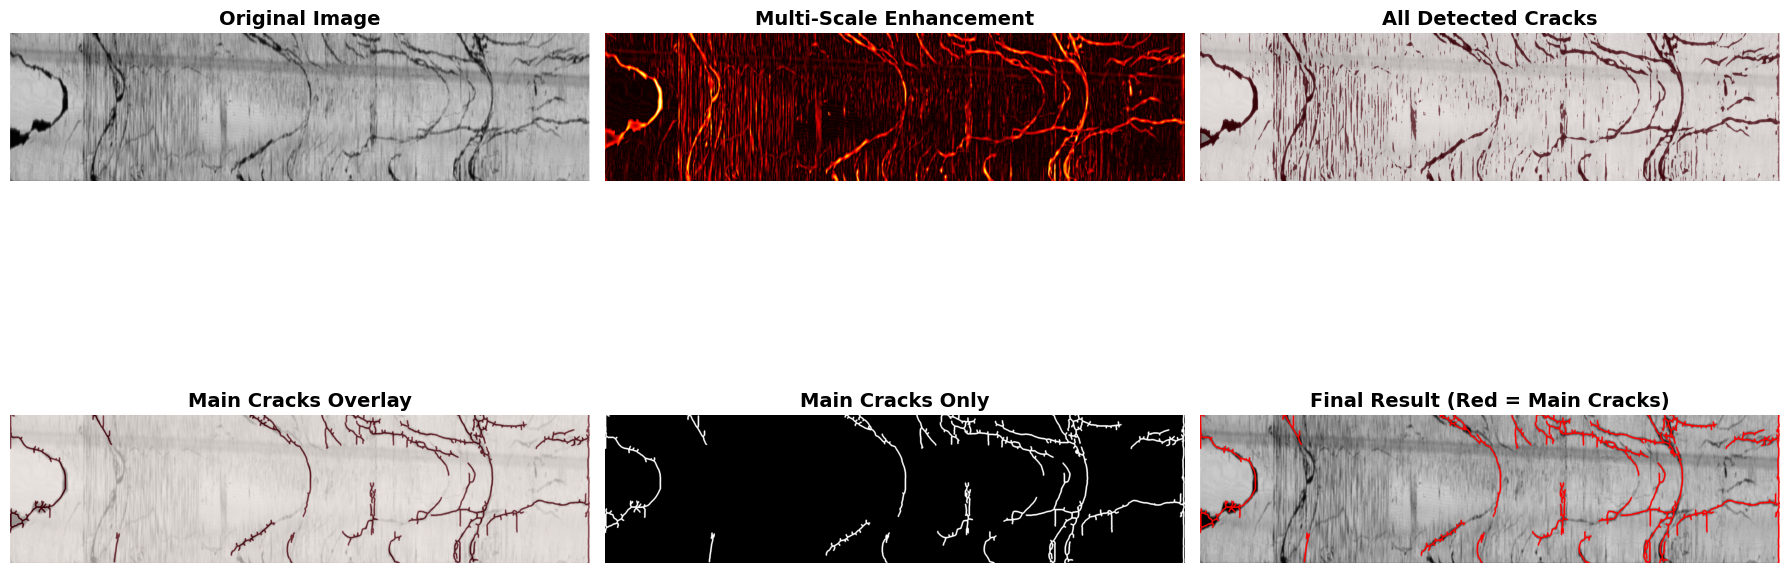


Processing complete!

✓ Successfully processed Well1.jpg

Processing: well2.png
1. Loading and preprocessing image...
2. Enhancing cracks using multi-scale ridge detection...
3. Segmenting cracks...
4. Extracting crack skeletons...
5. Extracting crack features...
   Found 237 crack components
6. Classifying main cracks...
   Identified 11 main cracks
7. Generating main crack mask...
8. Visualizing results...


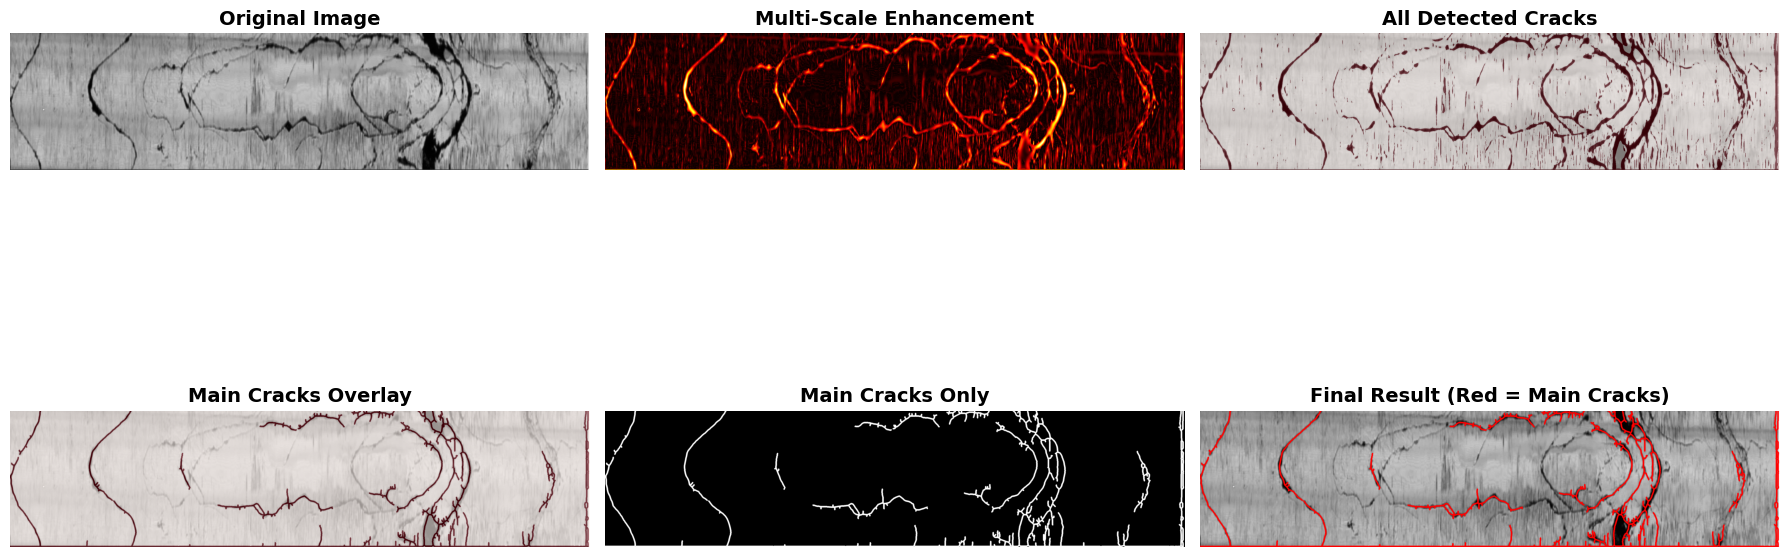


Processing complete!

✓ Successfully processed well2.png



In [27]:
all_results = {}

for image_path in image_paths:
    try:
        # results = process_wellbore_image(
        #     image_path,
        #     sigmas=range(1, 10, 1),  # Multi-scale from 1 to 9 pixels
        #     continuity_threshold=0.5,  # Must span 50% of image width
        #     width_percentile=60,
        #     length_percentile=70,
        #     save_result=True
        # )
        results = process_wellbore_image(
            image_path,
            sigmas=range(1, 10, 1),
            continuity_threshold=0.9,
            width_percentile=90,
            length_percentile=90,
            save_result=True
        )
        all_results[image_path] = results
        print(f"\n✓ Successfully processed {image_path}\n")
    except Exception as e:
        print(f"\n✗ Error processing {image_path}: {str(e)}\n")

## 10. Algorithm Summary and Explanation

### Algorithm Overview:

This algorithm uses a **multi-stage computer vision and signal processing pipeline**
to automatically identify main cracks in oil well bore images:

### Key Stages:

1. **Multi-Scale Ridge Enhancement**
   - Uses Frangi and Meijering filters to enhance crack-like structures
   - Works at multiple scales to detect cracks of varying widths
   - Based on Hessian matrix eigenvalue analysis

2. **Adaptive Segmentation**
   - Applies Otsu thresholding to create binary crack masks
   - Removes noise using morphological operations

3. **Skeletonization**
   - Reduces cracks to 1-pixel-wide centerlines
   - Preserves topology for connectivity analysis

4. **Feature Extraction**
   - **Continuity**: Horizontal span relative to image width
   - **Width**: Average thickness of crack
   - **Length**: Total skeleton length
   - **Aspect Ratio**: Horizontal vs vertical extent

5. **Rule-Based Classification**
   - Scores each crack based on multiple criteria
   - Main cracks must:
     * Span ≥50% of image width (high continuity)
     * Have above-average width (top 40%)
     * Have above-average length (top 30%)
     * Show horizontal orientation

6. **Result Visualization**
   - Overlays detected main cracks in red
   - Shows complete processing pipeline

### Why This Works:

- **Multi-scale analysis** captures cracks of different sizes
- **Ridge detection** specifically targets crack-like structures
- **Geometric features** distinguish continuous, wide cracks from noise
- **Rule-based classification** is interpretable and tunable

### Parameters to Tune:

- `sigmas`: Range of scales to detect (adjust for crack width range)
- `continuity_threshold`: How much of image width crack must span
- `width_percentile`: Threshold for "thick enough" cracks
- `length_percentile`: Threshold for "long enough" cracks